In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
BLUE, ORANGE, AQUA, GRAY, RED = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#e34948"
plt.rcParams.update({"figure.figsize": (11, 3.2), "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6, "axes.edgecolor": "#8a8984",
                     "lines.linewidth": 2, "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold", "legend.frameon": False, "date.converter": "concise", "xtick.labelsize": 8})

pd.set_option("display.width", 200)
DATA = "../data/"
sales = pd.read_csv(DATA + "sales_history.csv")
stock = pd.read_csv(DATA + "stock_history.csv")
promo = pd.read_csv(DATA + "promo_calendar.csv")
items = pd.read_csv(DATA + "item_master.csv")
for name, df in [("sales", sales), ("stock", stock), ("promo", promo), ("items", items)]:
    print(f"{name:6s} {df.shape}  {list(df.columns)}")

sales  (1526, 4)  ['sku', 'location', 'period', 'qty']
stock  (1523, 5)  ['sku', 'location', 'period', 'stock_end_qty', 'days_out_of_stock']
promo  (8, 4)  ['sku', 'period', 'promo_type', 'discount_pct']
items  (40, 6)  ['sku', 'category', 'abc_class', 'launch_period', 'predecessor_sku', 'uom']


## Проверяем структуру: ключ, частоту, длину рядов.

In [2]:
print("периоды:", sales.period.min(), "…", sales.period.max(), "| уникальных:", sales.period.nunique())
print("локации:", sales.location.value_counts().to_dict())
length = sales.drop_duplicates().groupby(["sku", "location"]).size()
print("рядов (sku×location):", len(length))
print("распределение длины ряда:")
print(length.value_counts().sort_index(ascending=False).to_string())

периоды: 2023-01 … 2025-12 | уникальных: 36
локации: {'MSK': 1310, 'EKB': 216}
рядов (sku×location): 46
распределение длины ряда:
36    40
32     1
21     1
15     1
5      3


## Проверим качество

In [3]:
print("пропуски в ячейках:\n", sales.isna().sum().to_string())
print("\nполные дубли строк:", sales.duplicated().sum())
print(sales[sales.duplicated(keep=False)].to_string())
print("\nдубли ключа с РАЗНЫМ qty:", sales.drop_duplicates().duplicated(["sku", "location", "period"]).sum())

пропуски в ячейках:
 sku         0
location    0
period      0
qty         0

полные дубли строк: 3
           sku location   period  qty
156   SKU_0004      MSK  2024-01  609
157   SKU_0004      MSK  2024-01  609
763   SKU_0019      MSK  2025-02  104
764   SKU_0019      MSK  2025-02  104
1148  SKU_0030      MSK  2023-04  571
1149  SKU_0030      MSK  2023-04  571

дубли ключа с РАЗНЫМ qty: 0


In [4]:
s = sales.drop_duplicates().copy()
print("отрицательные:\n", s[s.qty < 0].to_string())
print("\nсоседи этой точки:")
print(s[(s.sku == "SKU_0014") & s.period.between("2024-03", "2024-09")].to_string(index=False))

отрицательные:
           sku location   period  qty
539  SKU_0014      MSK  2024-06   -8

соседи этой точки:
     sku location  period  qty
SKU_0014      MSK 2024-03 1591
SKU_0014      MSK 2024-04 1896
SKU_0014      MSK 2024-05 1333
SKU_0014      MSK 2024-06   -8
SKU_0014      MSK 2024-07 1254
SKU_0014      MSK 2024-08 2057
SKU_0014      MSK 2024-09 1662


## Пропущенные месяцы

In [5]:
full = pd.period_range("2023-01", "2025-12", freq="M").astype(str)
rows = []
for (sku, loc), g in s.groupby(["sku", "location"]):
    inside = [p for p in full if g.period.min() <= p <= g.period.max()]
    gaps = sorted(set(inside) - set(g.period))
    rows.append({"sku": sku, "location": loc, "first": g.period.min(), "last": g.period.max(), "n": len(g), "gaps_inside": gaps})
cal = pd.DataFrame(rows)
print(cal[(cal.n < 36)].to_string(index=False))

     sku location   first    last  n                          gaps_inside
SKU_0005      MSK 2023-01 2025-12 32 [2023-07, 2023-08, 2024-08, 2025-05]
SKU_0011      MSK 2023-01 2024-09 21                                   []
SKU_0026      MSK 2025-08 2025-12  5                                   []
SKU_0029      MSK 2025-08 2025-12  5                                   []
SKU_0035      MSK 2025-08 2025-12  5                                   []
SKU_0036      MSK 2024-10 2025-12 15                                   []


In [6]:
print(items[items.sku.isin(["SKU_0005", "SKU_0011", "SKU_0026", "SKU_0029", "SKU_0035", "SKU_0036"])].to_string(index=False))
print("\nесть ли строки остатков для пропущенных месяцев SKU_0005?")
print(stock[(stock.sku == "SKU_0005") & stock.period.isin(["2023-07", "2023-08", "2024-08", "2025-05"])])

     sku  category abc_class launch_period predecessor_sku uom
SKU_0005     SNACK         C       2023-01             NaN PCS
SKU_0011 HOUSEHOLD         C       2023-01             NaN PCS
SKU_0026     DAIRY         C       2025-08             NaN PCS
SKU_0029     SNACK         C       2025-08             NaN PCS
SKU_0035 HOUSEHOLD         C       2025-08             NaN PCS
SKU_0036  BEVERAGE         A       2024-10        SKU_0011 PCS

есть ли строки остатков для пропущенных месяцев SKU_0005?
Empty DataFrame
Columns: [sku, location, period, stock_end_qty, days_out_of_stock]
Index: []


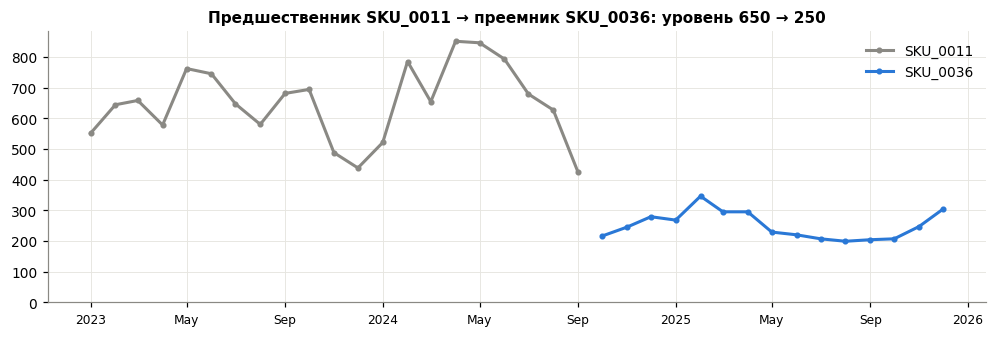

     sku  category abc_class
SKU_0011 HOUSEHOLD         C
SKU_0036  BEVERAGE         A


In [7]:
fig, ax = plt.subplots()
for sku, color in [("SKU_0011", GRAY), ("SKU_0036", BLUE)]:
    g = s[s.sku == sku]
    ax.plot(pd.PeriodIndex(g.period, freq="M").to_timestamp(), g.qty, color=color, label=sku, marker="o", ms=3)
ax.set_title("Предшественник SKU_0011 → преемник SKU_0036: уровень 650 → 250"); ax.legend(); ax.set_ylim(0); plt.show()
print(items[items.sku.isin(["SKU_0011", "SKU_0036"])][["sku", "category", "abc_class"]].to_string(index=False))

## Нули

In [8]:
m = s.merge(stock, on=["sku", "location", "period"], how="left")
zeros = m[m.qty == 0]
print("нулей всего:", len(zeros))
print(zeros.groupby("sku").agg(zeros=("qty", "size"), with_oos=("days_out_of_stock", lambda x: (x > 0).sum())).to_string())
print("\nзначения days_out_of_stock в данных:", sorted(stock.days_out_of_stock.unique()))

нулей всего: 163
          zeros  with_oos
sku                      
SKU_0002     27         0
SKU_0007      2         2
SKU_0009     26         0
SKU_0012      3         3
SKU_0015     27         0
SKU_0021      1         1
SKU_0024     27         0
SKU_0031     22         0
SKU_0033      2         2
SKU_0038      2         2
SKU_0040     24         0

значения days_out_of_stock в данных: [np.int64(0), np.int64(30)]


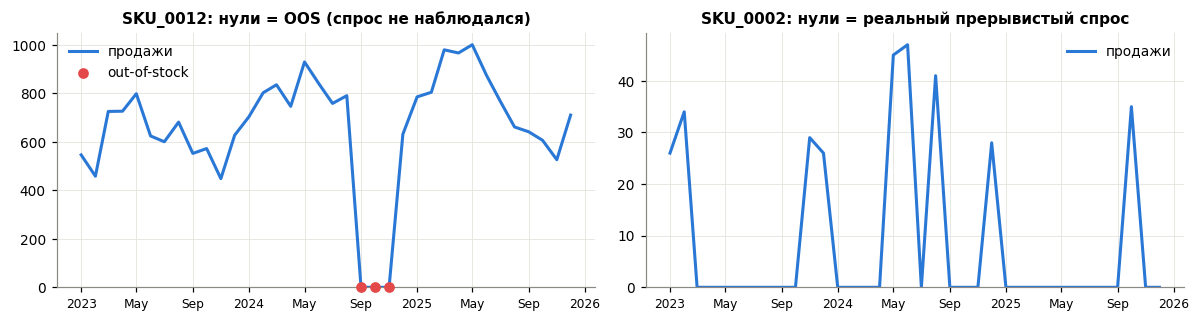

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
for ax, sku in zip(axes, ["SKU_0012", "SKU_0002"]):
    g = m[m.sku == sku]; t = pd.PeriodIndex(g.period, freq="M").to_timestamp()
    ax.plot(t, g.qty, color=BLUE, label="продажи")
    oos = g.days_out_of_stock > 0
    ax.scatter(t[oos], g.qty[oos], color=RED, zorder=3, s=36, clip_on=False, label="out-of-stock" if oos.any() else None)
    ax.set_title(f"{sku}: " + ("нули = OOS (спрос не наблюдался)" if oos.any() else "нули = реальный прерывистый спрос")); ax.legend(); ax.set_ylim(0)
plt.tight_layout(); plt.show()

## Аномалии

In [10]:
w = s.pivot_table(index=["sku", "location"], columns="period", values="qty")
ratio = w.div(w.median(axis=1), axis=0)
spikes = ratio.stack().rename("x_median").reset_index()
spikes = spikes[(spikes.x_median > 2.3) & (w.median(axis=1).reindex(pd.MultiIndex.from_frame(spikes[["sku", "location"]])).values > 50)]
spikes = spikes.merge(promo, on=["sku", "period"], how="left")
print(spikes.round(1).to_string(index=False))

     sku location  period  x_median promo_type  discount_pct
SKU_0001      MSK 2023-11       4.1        TPR          25.0
SKU_0001      MSK 2024-11       4.1        TPR          25.0
SKU_0006      MSK 2024-03       3.9        TPR          25.0
SKU_0013      MSK 2025-04       4.4        TPR          25.0
SKU_0018      MSK 2024-07       4.0        NaN           NaN
SKU_0018      MSK 2024-08       3.4        NaN           NaN
SKU_0018      MSK 2024-09       3.7        NaN           NaN
SKU_0018      MSK 2024-10       2.7        NaN           NaN
SKU_0018      MSK 2024-11       2.9        NaN           NaN
SKU_0018      MSK 2024-12       2.6        NaN           NaN
SKU_0018      MSK 2025-01       2.3        NaN           NaN
SKU_0018      MSK 2025-03       2.6        NaN           NaN
SKU_0018      MSK 2025-04       3.2        NaN           NaN
SKU_0018      MSK 2025-05       3.3        NaN           NaN
SKU_0018      MSK 2025-06       3.5        NaN           NaN
SKU_0018      MSK 2025-0

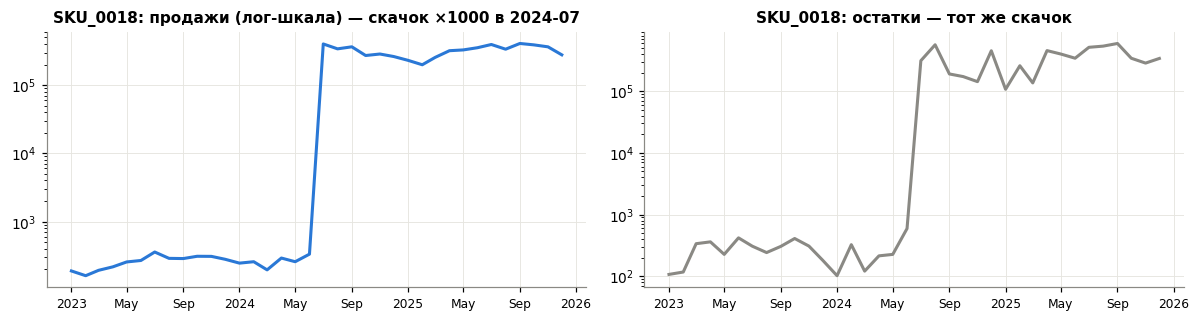

медиана до: 263.5 | после: 331304.0 | отношение: 1257


In [11]:
g = m[m.sku == "SKU_0018"]; t = pd.PeriodIndex(g.period, freq="M").to_timestamp()
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].plot(t, g.qty, color=BLUE); axes[0].set_yscale("log"); axes[0].set_title("SKU_0018: продажи (лог-шкала) — скачок ×1000 в 2024-07")
axes[1].plot(t, g.stock_end_qty, color=GRAY); axes[1].set_yscale("log"); axes[1].set_title("SKU_0018: остатки — тот же скачок")
plt.tight_layout(); plt.show()
print("медиана до:", g.qty[:18].median(), "| после:", g.qty[18:].median(), "| отношение:", round(g.qty[18:].median() / g.qty[:18].median()))

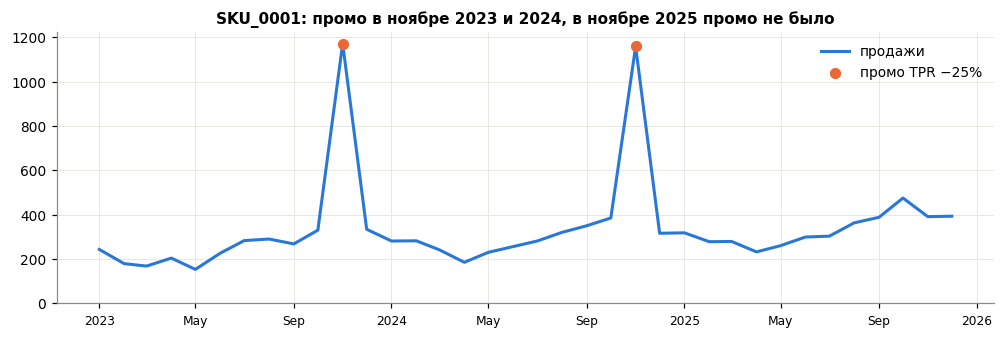

In [12]:
fig, ax = plt.subplots()
g = s[s.sku == "SKU_0001"]; t = pd.PeriodIndex(g.period, freq="M").to_timestamp()
ax.plot(t, g.qty, color=BLUE, label="продажи")
pm = g.period.isin(promo[promo.sku == "SKU_0001"].period)
ax.scatter(t[pm], g.qty[pm], color=ORANGE, s=40, zorder=3, label="промо TPR −25%")
ax.set_title("SKU_0001: промо в ноябре 2023 и 2024, в ноябре 2025 промо не было"); ax.legend(); ax.set_ylim(0); plt.show()

## Локации

In [13]:
r = (w.xs("EKB", level="location") / w.xs("MSK", level="location")).dropna(how="all")
print(pd.DataFrame({"доля EKB/MSK": r.mean(axis=1).round(3), "std доли": r.std(axis=1).round(4)}).to_string())

          доля EKB/MSK  std доли
sku                             
SKU_0003         0.430    0.0005
SKU_0008         0.334    0.0005
SKU_0017         0.259    0.0026
SKU_0022         0.422    0.0002
SKU_0027         0.348    0.0002
SKU_0034         0.488    0.0005


## Смотрим виды рядов

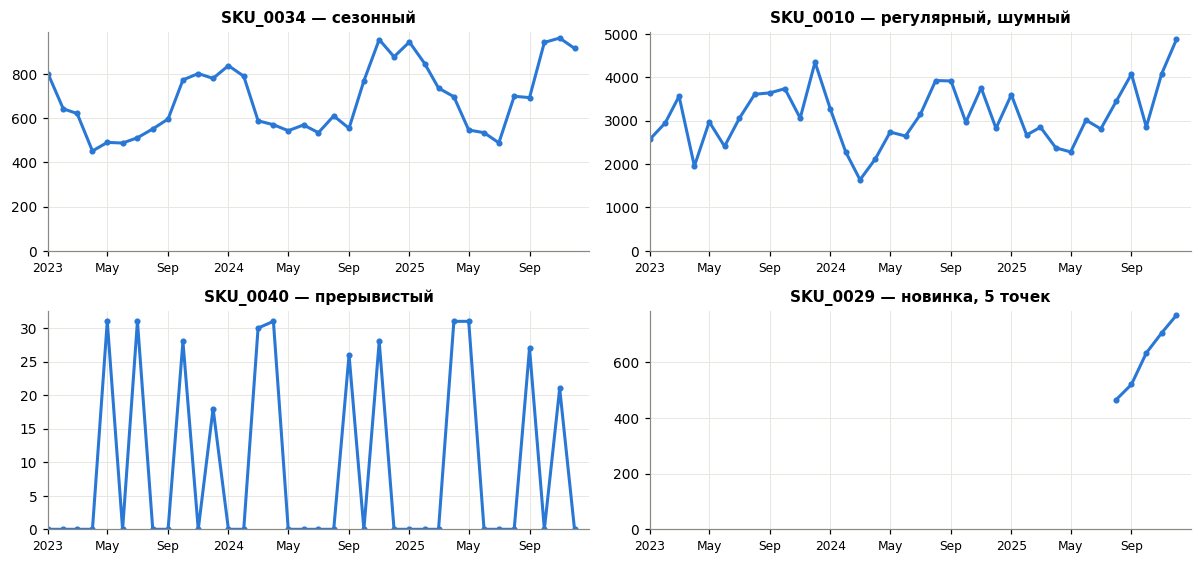

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(11, 5.2))
for ax, (sku, title) in zip(axes.ravel(), [("SKU_0034", "сезонный"), ("SKU_0010", "регулярный, шумный"), ("SKU_0040", "прерывистый"), ("SKU_0029", "новинка, 5 точек")]):
    g = s[(s.sku == sku) & (s.location == "MSK")]
    ax.plot(pd.PeriodIndex(g.period, freq="M").to_timestamp(), g.qty, color=BLUE, marker="o", ms=3)
    ax.set_title(f"{sku} — {title}"); ax.set_ylim(0); ax.set_xlim(pd.Timestamp("2023-01-01"), pd.Timestamp("2025-12-31"))
plt.tight_layout(); plt.show()